In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba
import torch
torch.set_grad_enabled(False)

/iridisfs/home/lhl1g23/ssm/mamba


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [16]:
from models.dataloaders.selective_copying import generate_dataset
from models.configs.selective_copying.config import training_config, dataset_config, MambaConfig
from models.selective_copying_mamba import validate
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
import matplotlib.pyplot as plt
import torch

X, y = generate_dataset(dataset_config, training_config)
X, y = X.to("cuda"), y.to("cuda")

model = MambaLMHeadModel(MambaConfig, device="cuda")
model.load_state_dict(torch.load("checkpoints/selective_copying.pt", weights_only=True))

pred = model(X, num_last_tokens=dataset_config['l_memorize']).logits.argmax(1)

In [20]:
hidden_states = model.backbone.embedding(X)
A, B, C, D, dt, dA, dB, states, y_ssm = model.backbone.layers[1].mixer.get_parameters(hidden_states)

tensor([ 0,  0,  0,  ..., 15, 15, 15], device='cuda:0')

In [57]:
import scipy
print(scipy.signal.find_peaks(X[0].to('cpu')))
scipy.signal.find_peaks(dt[0,:,19])[0]

(array([ 311,  810,  986, 1169, 1383, 1449, 1776, 1798, 2167, 3015, 3204,
       3329, 3617, 3818, 3871, 3946]), {})


array([ 312,  811,  987, 1170, 1384, 1450, 1777, 1799, 2167, 3016, 3205,
       3329, 3617, 3819, 3872, 3947])

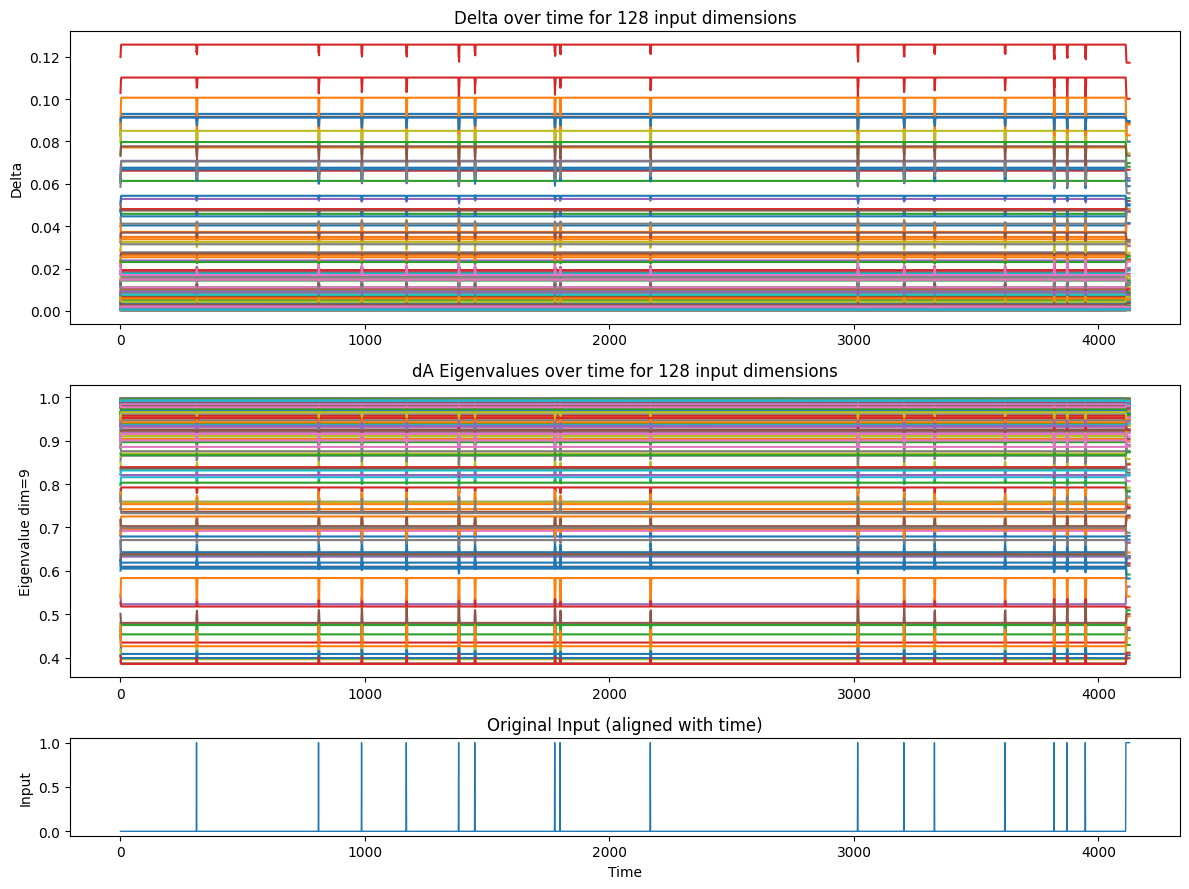

In [ ]:
import matplotlib.pyplot as plt
import torch

sample = 0
start = 0
n_din = 128

with torch.no_grad():
    b,l,d,n = dA.shape
    
    fig = plt.figure(figsize=(12,9))
    gs = fig.add_gridspec(3, 1, height_ratios=[3,3,1])
    
    ax0 = fig.add_subplot(gs[0,0])
    ax1 = fig.add_subplot(gs[1,0])
    ax_input = fig.add_subplot(gs[2,0], sharex=ax0)  
    
    for i in range(start, start + n_din):
        ax0.plot(dt[sample,:,i])
    ax0.set_title(f"Delta over time for {n_din} input dimensions")
    ax0.set_ylabel("Delta")
    
    for i in range(start, start + n_din):
        ax1.plot(dA[sample,:,i,9])
    ax1.set_title(f"dA Eigenvalues over time for {n_din} input dimensions")
    ax1.set_ylabel("Eigenvalue dim=9")

    x = (X != 0).int().to('cpu')[sample]
    ax_input.plot(x, linewidth=1.0)
    ax_input.set_title("Original Input (aligned with time)")
    ax_input.set_xlabel("Time")
    ax_input.set_ylabel("Input")
    
    plt.tight_layout()
    plt.show()


In [62]:
x.shape

torch.Size([64, 4128])

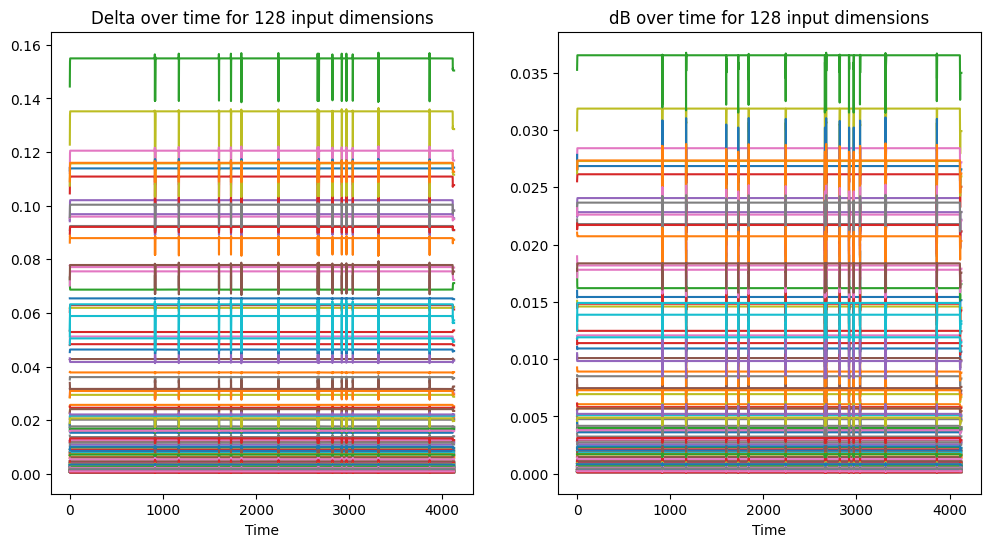

In [8]:
start = 0
n_din = 128
fig, ax = plt.subplots(1,2, figsize=(12,6))

with torch.no_grad():
    b,l,d,n = dB.shape
    for i in range(start, start + n_din):
        y_axis = dt[sample,:,i]
        ax[0].plot(y_axis)
            
    for i in range(start, start + n_din):
        y_axis = dB[sample,:,i,5]
        ax[1].plot(y_axis)

ax[0].set_xlabel("Time")
ax[0].set_title(f"Delta over time for {n_din} input dimensions")
ax[1].set_xlabel("Time")
ax[1].set_title(f"dB over time for {n_din} input dimensions")
plt.show()

In [41]:
dA.shape

torch.Size([2, 4128, 128, 16])

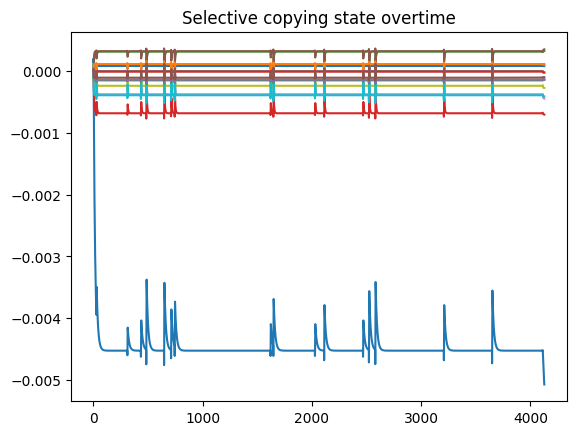

In [113]:
with torch.no_grad():
    plt.plot(states[1,:,0,:])
    plt.title("Selective copying state overtime")

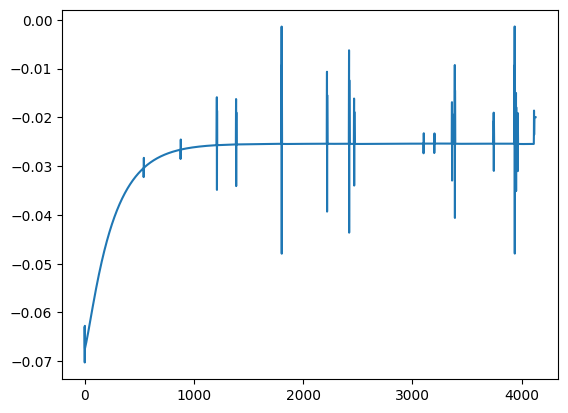

In [ ]:
with torch.no_grad():
    plt.plot(y_ssm[0,:,3])

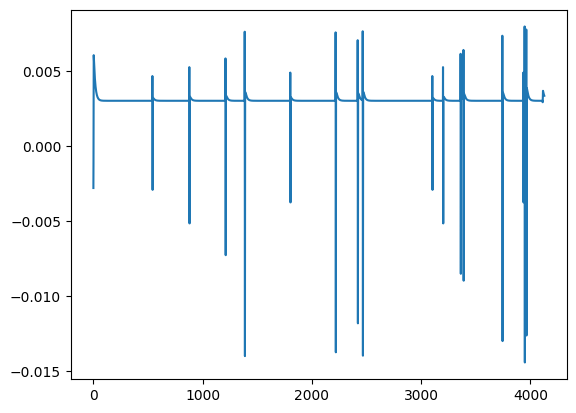

In [107]:
plt.plot(y_ssm[0,:,0])

In [112]:
model(X).logits.shape

AttributeError: 'Delete' object has no attribute 'value'

torch.Size([64, 4128, 16])

In [68]:
pred = model(X)

In [71]:
pred.logits.shape

torch.Size([64, 4128, 16])

In [11]:
mask = (X != 0) & (X != 15)
idx = torch.nonzero(mask)  


batch_idx, seq_idx = idx[:, 0], idx[:, 1]
counts = torch.bincount(batch_idx, minlength=X.shape[0])

grouped_indices = torch.split(seq_idx, counts.tolist())

grouped_indices = torch.tensor([g.tolist() for g in grouped_indices])

In [26]:
grouped_indices[0]

tensor([ 540,  878, 1209, 1385, 1802, 2217, 2419, 2465, 3102, 3200, 3361, 3387,
        3743, 3935, 3947, 3962])

In [28]:
X[0,541]

tensor(0, device='cuda:0')

In [10]:
dt_mean = torch.mean(dt[sample], dim=1)

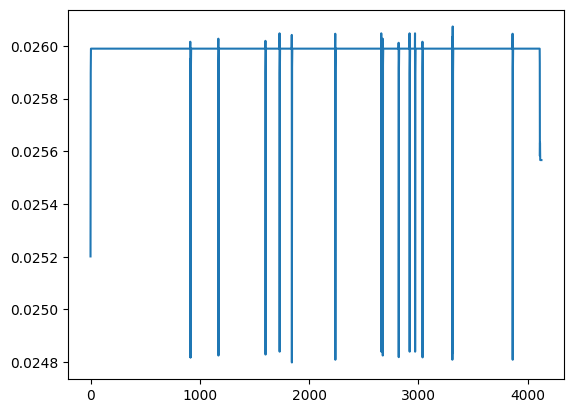

In [15]:
plt.plot(dt_mean)